In [5]:
import sys
sys.path.insert(0, '../../')

In [6]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.base import clone
from tqdm import tqdm
from pickle import load
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

# load local variables
from src.config import *
from src.load_models import select_model
from src.utils import calculate_r2_score, calculate_per_diff
from src.utils import calculate_y_LOD, find_score
from src.feature_selection import ModelSelection
from src.graph_visualization import feature_selection_tabularize, plot_model_vs_score, visualization_class_stratified
from src.outlier_detection import find_outliers_remove
from src.utils import evaluate_score_class_stratified

from sklearn.ensemble  import RandomForestClassifier

from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process.kernels import Matern, RBF

from scipy.stats import ks_2samp
from scipy.stats import ttest_ind, levene

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

In [39]:
def ValidationPerformanceWithStratified(X:pd.DataFrame,
                                        y:pd.Series,
                                        models:list,
                                        save_dir:str,
                                        kf:KFold,
                                        features_list:dict, 
                                        param_list:dict,
                                        y_LOD:float = 1.0163597575709407,
                                        use_classifier:bool=False,
                                        remove_zero:bool=False) -> None:

    
    per_diff_class_stratified_test = {'Models':[]}
    for key in sorted(y.unique())[(1 if (remove_zero) else 0): ]:
        per_diff_class_stratified_test[str(key)] = []
    
    os.makedirs(save_dir, exist_ok=True)
 
    for metric in ['r2', 'per_diff']:
        test_score = {'Models':[], 'Scores':[]}
        
        for model_name in models:
            model = select_model('Linear')
                
            selected_feature_set = features_list[model_name]

            # Set the model parameters extrinsic
            # model.set_params(**param_list[model_name])
            
            # Calculate the test score on the given performance metrics
            test_score['Models'].append(model_name)

            y_pred_all, y_true_all = [], []
       
            # Calculate score for each folds
            for train_index, test_index in kf.split(X):
                model_ = clone(model)

                # Split the data into training and testing sets
                X_train  = X.iloc[train_index]
                y_train  = y.iloc[train_index]
                
                X_test   = X.iloc[test_index]
                y_test   = y.iloc[test_index]

                model_.fit(X_train[selected_feature_set], y_train)        # Train only on selected features
                y_pred = model_.predict(X_test[selected_feature_set])

                y_pred_all.append(y_pred)
                y_true_all.append(y_test)


            y_pred_all = np.concatenate(y_pred_all, axis=0) 
            y_true_all = np.concatenate(y_true_all, axis=0) 

            
            # Remove zero concentration calculating
            if  remove_zero:
                y_pred_all      = pd.Series(y_pred_all)
                y_true_all      = pd.Series(y_true_all)
                
                indx_gt_zero    = list(y_true_all[y_true_all!=0].index)
                y_pred_all      = y_pred_all.loc[indx_gt_zero].to_numpy()
                y_true_all      = y_true_all.loc[indx_gt_zero].to_numpy()

            
            if metric == 'r2': score = calculate_r2_score(y_true_all, y_pred_all)
            else: score = calculate_per_diff(y_true_all, y_pred_all, y_LOD)

            test_score['Scores'].append(score)

        save_path = os.path.join(save_dir, f'val_results_{metric}.png')
        df_test_score = pd.DataFrame(test_score)
        df_test_score = df_test_score.sort_values(by='Scores')
        plot_model_vs_score(df_test_score, metric, save_path)
        plt.show()

In [40]:
y_LOD = 1.0163597575709407

dataset_name = 'ML6'
remove_zero  = True
dataset_root = '../../dataset'

# Load Extracted features dataset
ML6_1 = pd.read_excel(f'{dataset_root}/ML6/Day 1 Data/feature_extraction_noise_None.xlsx')
ML6_2 = pd.read_excel(f'{dataset_root}/ML6/Day 2 Data/feature_extraction_noise_None.xlsx')

ML6_1['dataset_name'] = '1'
ML6_2['dataset_name'] = '2'
final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)
final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)
final_dataset['label'] = final_dataset['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))

final_dataset.rename(columns={"PH": 'max(S)', 'signal_std':'std(S)', 'signal_mean':'mean(S)', 'peak area':'area(S)', \
                        'dS_dV_area':'area(dS/dV)', 'dS_dV_max_peak':'max(dS/dV)', 'dS_dV_min_peak':'min(dS/dV)',\
                    'dS_dV_peak_diff':'max(dS/dV) - min(dS/dV)', \
                    'peak V':'V_max(S)', 'dS_dV_max_V':'V_max(dS/dV)', 'dS_dV_min_V':'V_min(dS/dV)',\
        }, inplace = True)

final_dataset = final_dataset[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2', 'file', 'label']]

train, test           = train_test_split(final_dataset, test_size=0.4, shuffle=True, random_state=42, stratify=final_dataset['label'])


X_train = train[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2']]
y_train  = train['label']

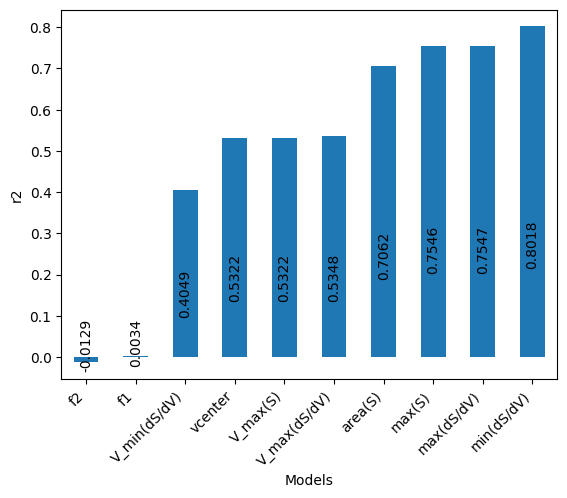

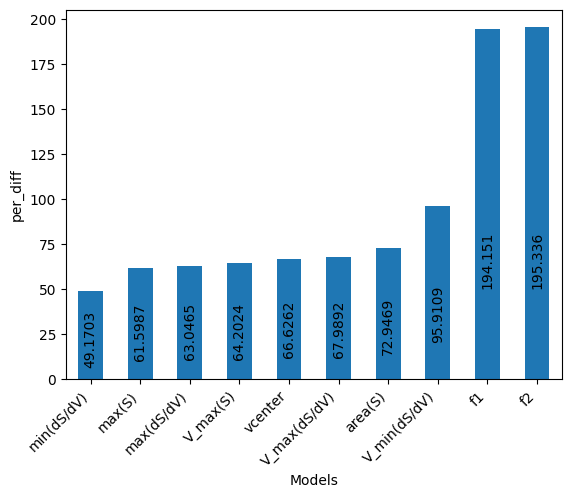

In [41]:
# With V_outlier removal
features_list = {f'{feature}':[feature] for indx, feature in enumerate(X_train.columns)}
param_list    =  {'Linear': {}}
models        =  list(features_list.keys())

root_dir    = f'../../results/Journal_paper/{dataset_name}_univariate_linear_model'
weight_path = '../../weights/Journal_paper'

kf        = KFold(n_splits=5, shuffle=True, random_state=42) 

ValidationPerformanceWithStratified(X_train, 
                                    y_train, 
                                    models, 
                                    root_dir, 
                                    kf=kf, 
                                    features_list=features_list, 
                                    param_list= param_list, 
                                    y_LOD=y_LOD,
                                    remove_zero=False,
                                    use_classifier=False)